In [551]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [553]:
# Load the California Housing dataset
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target  # Target variable

In [555]:
# Check for missing values
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [557]:
# Display the first few rows for reference
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [559]:
# Display data types for reference
print("Data types:")
print(df.dtypes)

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [561]:
# Basic Exploratory Data Analysis (EDA)
# Display summary statistics
print("Summary statistics:")
print(df.describe())

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0

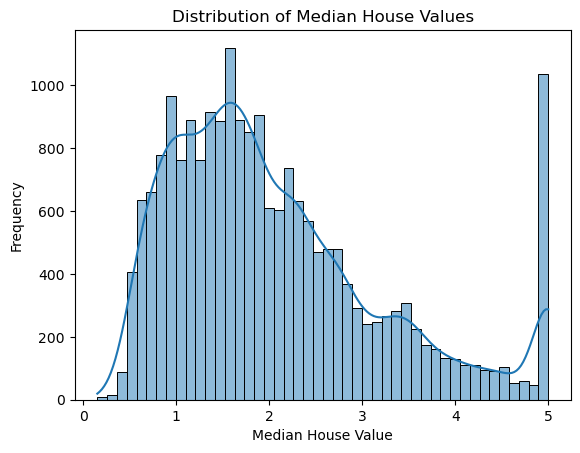

In [563]:
# Plot distribution of the target variable (median house value)
sns.histplot(df['MedHouseVal'], kde=True)
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

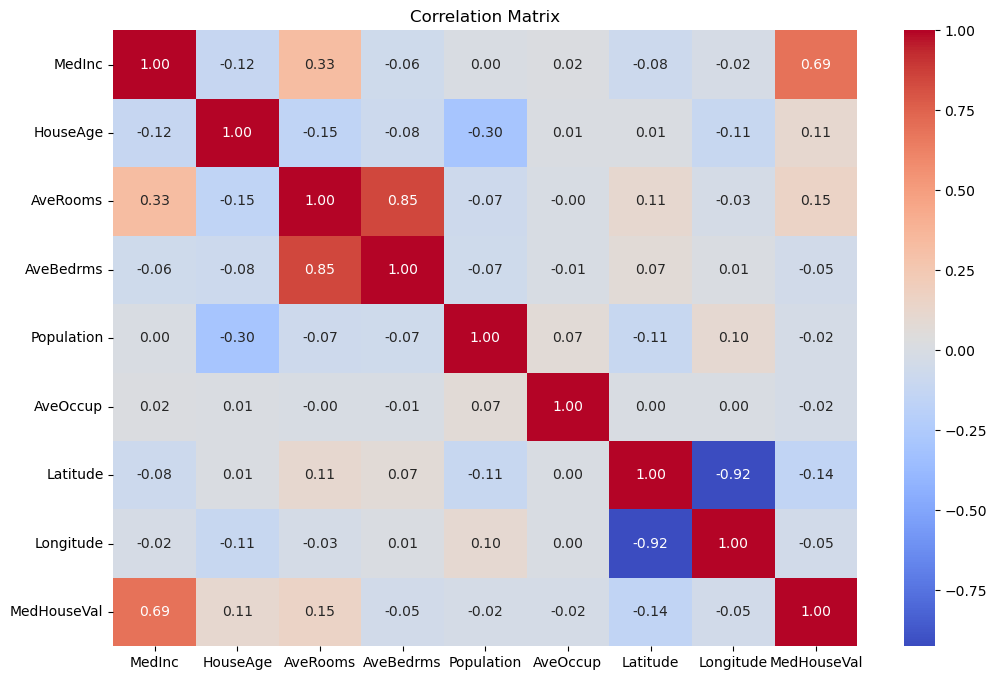

In [564]:
# Correlation matrix to understand relationships between features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [565]:
# Define features (X) and target (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [569]:
# Log transform the target variable to handle skewness
y = np.log1p(y)

In [571]:
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [573]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [575]:
# Adding polynomial features to capture non-linear relationships
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

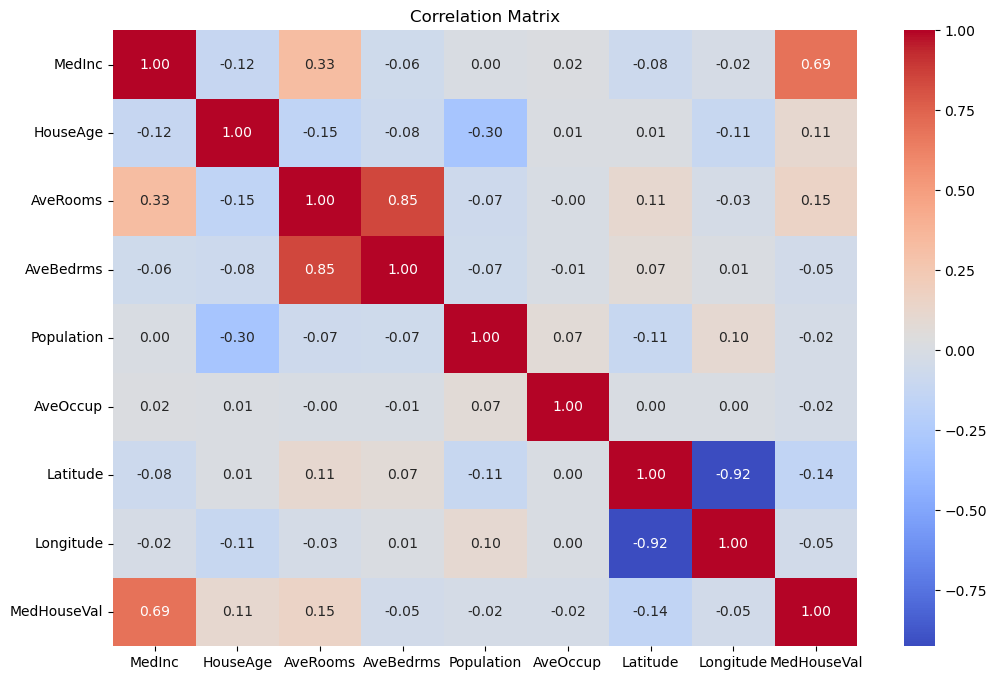

In [577]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [579]:
# Initialize the Linear Regression model
model = LinearRegression()

In [581]:
# Train the model
model.fit(X_train_poly, y_train)

LinearRegression()

In [583]:
# Make predictions on the test set
y_pred = model.predict(X_test_poly)

In [585]:
# Convert predictions back to original scale by applying the exponential function
y_test_exp = np.expm1(y_test)  # Reverse log transform on the actual values
y_pred_exp = np.expm1(y_pred)  # Reverse log transform on the predicted values

In [587]:
# Evaluate the model
mse = mean_squared_error(y_test_exp, y_pred_exp)
r2 = r2_score(y_test_exp, y_pred_exp)

In [589]:
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 0.45
R-squared (R²): 0.65


In [591]:
print(f"R-squared (R²): {r2:.2f}")
r2 = r2_score(y_test, y_pred)

R-squared (R²): 0.65


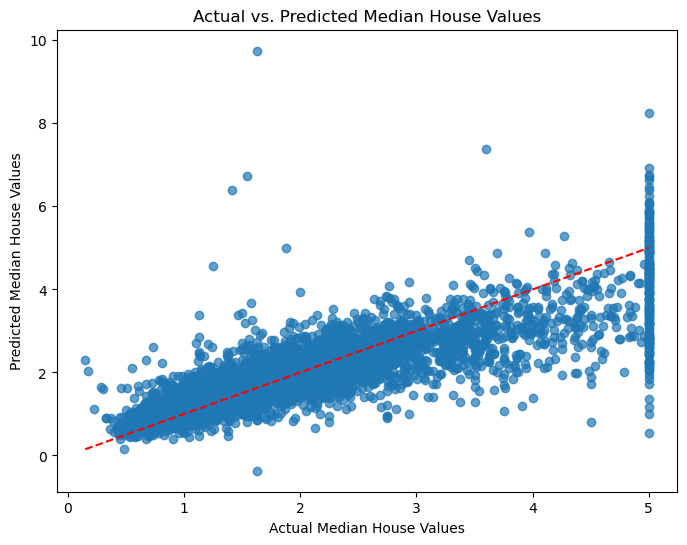

In [593]:
# Plot predicted vs. actual prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test_exp, y_pred_exp, alpha=0.7)
plt.xlabel('Actual Median House Values')
plt.ylabel('Predicted Median House Values')
plt.title('Actual vs. Predicted Median House Values')
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], 'r--')  # Diagonal line for reference
plt.show()

In [595]:
# Analysis of model performance
if r2 > 0.8:
    print("The model performs well with a high R-squared value.")
elif r2 > 0.5:
    print("The model has moderate performance, but there might be room for improvement.")
else:
    print("The model may be underfitting the data.")

The model has moderate performance, but there might be room for improvement.


In [597]:
print("Observations:")
print("- MSE indicates the average squared difference between predicted and actual values.")
print("- R² shows the proportion of variance in the target variable explained by the model.")
print("- The scatter plot should ideally have points close to the diagonal, indicating good predictions.")

Observations:
- MSE indicates the average squared difference between predicted and actual values.
- R² shows the proportion of variance in the target variable explained by the model.
- The scatter plot should ideally have points close to the diagonal, indicating good predictions.
